In [1]:
import pandas as pd

stocking = pd.read_csv("../../data/stocking.csv", index_col=0)
middle = pd.read_csv("../../data/middle.csv", index_col=0)
ctp = pd.read_csv("../../data/ctp.csv", index_col=0)
ctq = pd.read_csv("../../data/ctq.csv", index_col=0)

---

In [11]:
atob = pd.concat([stocking, middle], axis=1)

In [12]:
atob.info()

<class 'pandas.core.frame.DataFrame'>
Index: 605 entries, 0 to 604
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    605 non-null    object 
 1   RMth     605 non-null    object 
 2   No       605 non-null    int64  
 3   Class1   605 non-null    object 
 4   Class2   605 non-null    object 
 5   CaO      605 non-null    float64
 6   Al2O3    605 non-null    float64
 7   SiO2     605 non-null    float64
 8   Fe2O3    605 non-null    float64
 9   SO3      605 non-null    float64
 10  MgO      605 non-null    float64
 11  etc      605 non-null    float64
 12  FM       584 non-null    float64
 13  MeanV    569 non-null    float64
 14  Density  581 non-null    float64
 15  Blain    567 non-null    float64
dtypes: float64(11), int64(1), object(4)
memory usage: 80.4+ KB


In [13]:
atob

,Index,RMth,No,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain
0,210323-01,2020.09,1,세아,급결재,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.56,NaN,2.87,6012.000
1,210323-02,2020.09,2,세아,시멘트,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.56,NaN,2.87,6012.000
2,210323-03,2020.09,3,세아,시멘트,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.56,NaN,2.87,6012.000
3,210323-04,2020.09,4,세아,시멘트,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.56,NaN,2.87,6012.000
4,210427-01,2021.02,1,세아,급결재,55.21,24.35,6.04,1.08,5.500,6.74,1.080,NaN,NaN,2.87,6051.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,250224-02,2024.12,2,현대,시멘트,46.70,31.20,11.20,3.18,0.573,4.04,3.107,4.50,9.274,3.02,7127.000
601,250304-01,2024.11,1,세아,시멘트,49.10,27.28,11.62,1.18,4.290,5.42,1.110,3.36,12.260,2.97,5.858
602,250304-02,2024.11,1,세아,시멘트,49.10,27.28,11.62,1.18,4.290,5.42,1.110,3.36,12.260,2.97,5.858
603,250304-03,2024.12,1,현대,시멘트,46.70,31.20,11.20,3.18,0.573,4.04,3.107,4.50,9.274,3.02,7127.000


In [15]:
atob['Class2'].value_counts()

Class2
시멘트       478
급결재       110
기포콘크리트     17
Name: count, dtype: int64

In [17]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder

# 1. 제외할 열 지정
exclude_cols = ['Index', 'RMth', 'No']
target_cols = [col for col in atob.columns if col not in exclude_cols]

# 2. 수치형 + 범주형 분리
cat_cols = ['Class1', 'Class2']
num_cols = [col for col in target_cols if col not in cat_cols]

# 3. 원핫인코딩
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first'로 다중공선성 방지
cat_encoded = encoder.fit_transform(atob[cat_cols])
cat_encoded_df = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(cat_cols), index=atob.index)

# 4. 수치형 데이터 추출
num_df = atob[num_cols]

# 5. 결합하여 MICE에 투입할 전체 데이터 구성
mice_input_df = pd.concat([num_df, cat_encoded_df], axis=1)

# 6. MICE 적용
imputer = IterativeImputer(random_state=42)
mice_result = imputer.fit_transform(mice_input_df)

# 7. 복원
mice_result_df = pd.DataFrame(mice_result, columns=mice_input_df.columns)

# 필요하다면 원본과 결합 (선택 사항)
final_df = atob.copy()
for col in mice_input_df.columns:
    final_df[col] = mice_result_df[col]


In [18]:
mice_result_df

,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,Class1_현대,Class2_기포콘크리트,Class2_시멘트
0,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.560000,7.437700,2.87,6012.000,0.0,0.0,0.0
1,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.560000,7.100739,2.87,6012.000,0.0,0.0,1.0
2,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.560000,7.100739,2.87,6012.000,0.0,0.0,1.0
3,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.560000,7.100739,2.87,6012.000,0.0,0.0,1.0
4,55.21,24.35,6.04,1.08,5.500,6.74,1.080,2.097413,6.116165,2.87,6051.000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,46.70,31.20,11.20,3.18,0.573,4.04,3.107,4.500000,9.274000,3.02,7127.000,1.0,0.0,1.0
601,49.10,27.28,11.62,1.18,4.290,5.42,1.110,3.360000,12.260000,2.97,5.858,0.0,0.0,1.0
602,49.10,27.28,11.62,1.18,4.290,5.42,1.110,3.360000,12.260000,2.97,5.858,0.0,0.0,1.0
603,46.70,31.20,11.20,3.18,0.573,4.04,3.107,4.500000,9.274000,3.02,7127.000,1.0,0.0,1.0


In [20]:
final_df

,Index,RMth,No,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,Class1_현대,Class2_기포콘크리트,Class2_시멘트
0,210323-01,2020.09,1,세아,급결재,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.560000,7.437700,2.87,6012.000,0.0,0.0,0.0
1,210323-02,2020.09,2,세아,시멘트,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.560000,7.100739,2.87,6012.000,0.0,0.0,1.0
2,210323-03,2020.09,3,세아,시멘트,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.560000,7.100739,2.87,6012.000,0.0,0.0,1.0
3,210323-04,2020.09,4,세아,시멘트,50.71,27.52,8.15,2.23,3.950,5.80,1.640,2.560000,7.100739,2.87,6012.000,0.0,0.0,1.0
4,210427-01,2021.02,1,세아,급결재,55.21,24.35,6.04,1.08,5.500,6.74,1.080,2.097413,6.116165,2.87,6051.000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,250224-02,2024.12,2,현대,시멘트,46.70,31.20,11.20,3.18,0.573,4.04,3.107,4.500000,9.274000,3.02,7127.000,1.0,0.0,1.0
601,250304-01,2024.11,1,세아,시멘트,49.10,27.28,11.62,1.18,4.290,5.42,1.110,3.360000,12.260000,2.97,5.858,0.0,0.0,1.0
602,250304-02,2024.11,1,세아,시멘트,49.10,27.28,11.62,1.18,4.290,5.42,1.110,3.360000,12.260000,2.97,5.858,0.0,0.0,1.0
603,250304-03,2024.12,1,현대,시멘트,46.70,31.20,11.20,3.18,0.573,4.04,3.107,4.500000,9.274000,3.02,7127.000,1.0,0.0,1.0


---

### (1) 대체 전후 분포 비교
원래 결측치가 없던 행과 대체된 행의 분포가 비슷한지 비교

- 'FM' 컬럼에 대해 분포 비교

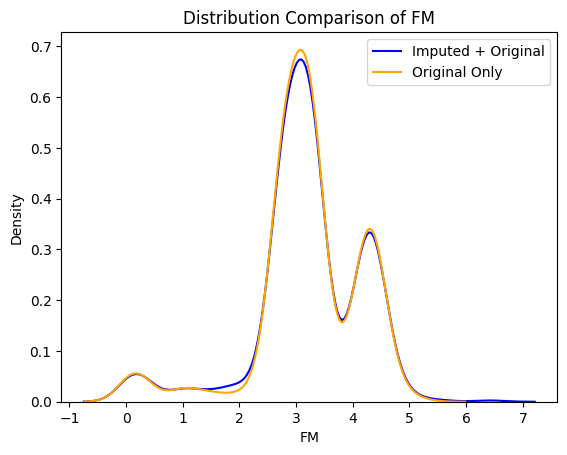

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=final_df['FM'], label='Imputed + Original', color='blue')
sns.kdeplot(data=atob['FM'].dropna(), label='Original Only', color='orange')
plt.legend()
plt.title('Distribution Comparison of FM')
plt.show()

- 'MeanV' 컬럼에 대해 분포 비교

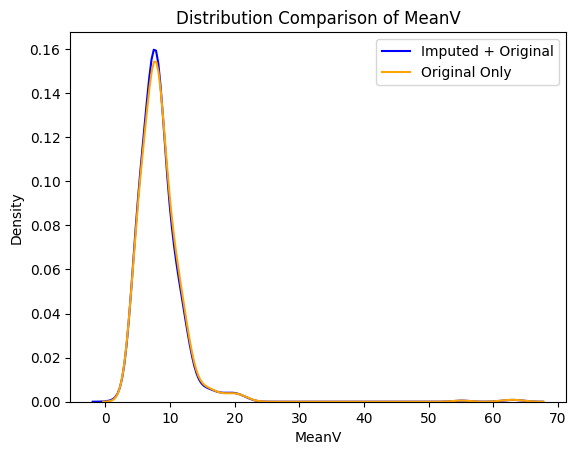

In [24]:
sns.kdeplot(data=final_df['MeanV'], label='Imputed + Original', color='blue')
sns.kdeplot(data=atob['MeanV'].dropna(), label='Original Only', color='orange')
plt.legend()
plt.title('Distribution Comparison of MeanV')
plt.show()

- 'Density' 컬럼에 대해 분포 비교

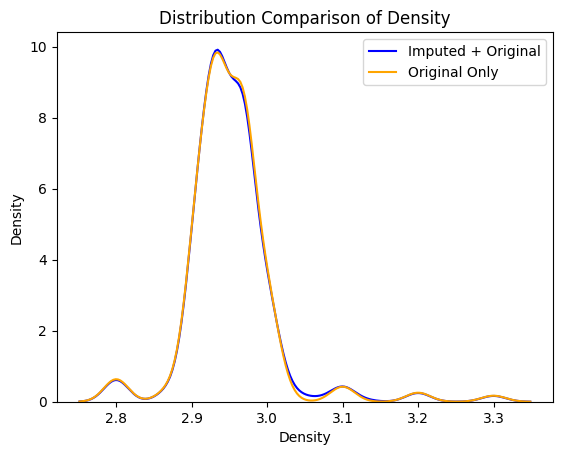

In [25]:
sns.kdeplot(data=final_df['Density'], label='Imputed + Original', color='blue')
sns.kdeplot(data=atob['Density'].dropna(), label='Original Only', color='orange')
plt.legend()
plt.title('Distribution Comparison of Density')
plt.show()

- 'Blain' 컬럼에 대해 분포 비교

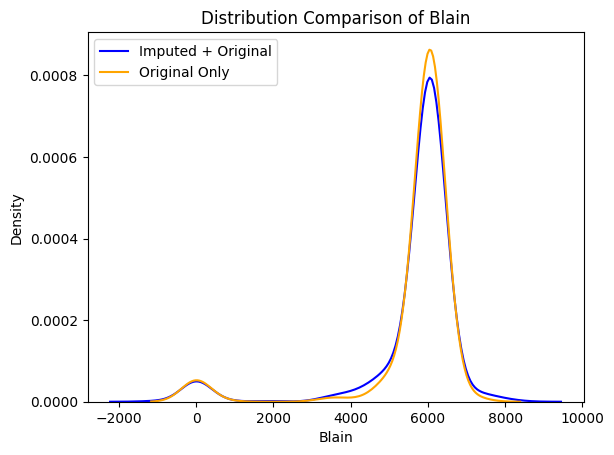

In [26]:
sns.kdeplot(data=final_df['Blain'], label='Imputed + Original', color='blue')
sns.kdeplot(data=atob['Blain'].dropna(), label='Original Only', color='orange')
plt.legend()
plt.title('Distribution Comparison of Blain')
plt.show()

#### 분석 포인트
- 두 커널 밀도 곡선이 거의 겹친다는 것은, MICE 방식이 원래의 데이터 분포를 크게 왜곡하지 않고 자연스럽게 보완되었음을 시사
- 분포의 주요 피크(모드)나 꼬리(tail) 위치가 비슷한지 여부를 확인하는 것도 중요
    - 피크(모드mode): 최빈값, 즉 분포에서 가장 높이 솟은 부분

---

### (2) 대체된 값 시각화 (Imputed indicator 활용)
결측이었던 값들만 따로 마킹해서 시각적으로 확인
- 가로축 : 데이터 인덱스 번호 (행번호)
- 세로축 : 각 컬럼 데이터의 실제 값 (결측치 대체 후)

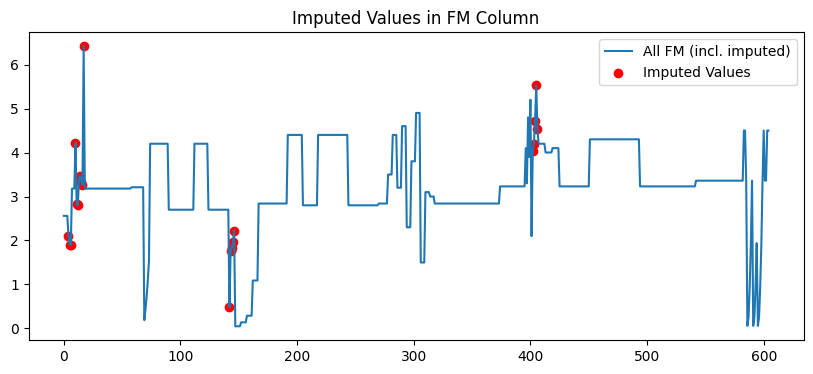

In [22]:
# 결측 여부 마스크
fm_missing_mask = atob['FM'].isna()

# 시각화
plt.figure(figsize=(10, 4))
plt.plot(final_df['FM'], label='All FM (incl. imputed)')
plt.scatter(final_df.index[fm_missing_mask], final_df['FM'][fm_missing_mask], color='red', label='Imputed Values')
plt.legend()
plt.title('Imputed Values in FM Column')
plt.show()


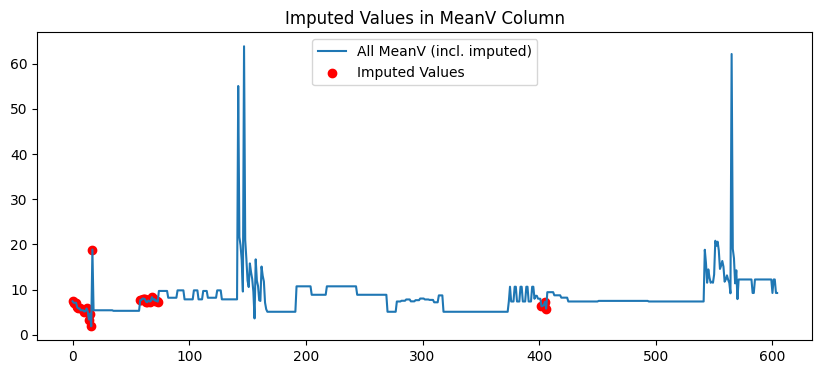

In [27]:
# 결측 여부 마스크
MeanV_missing_mask = atob['MeanV'].isna()

# 시각화
plt.figure(figsize=(10, 4))
plt.plot(final_df['MeanV'], label='All MeanV (incl. imputed)')
plt.scatter(final_df.index[MeanV_missing_mask], final_df['MeanV'][MeanV_missing_mask], color='red', label='Imputed Values')
plt.legend()
plt.title('Imputed Values in MeanV Column')
plt.show()

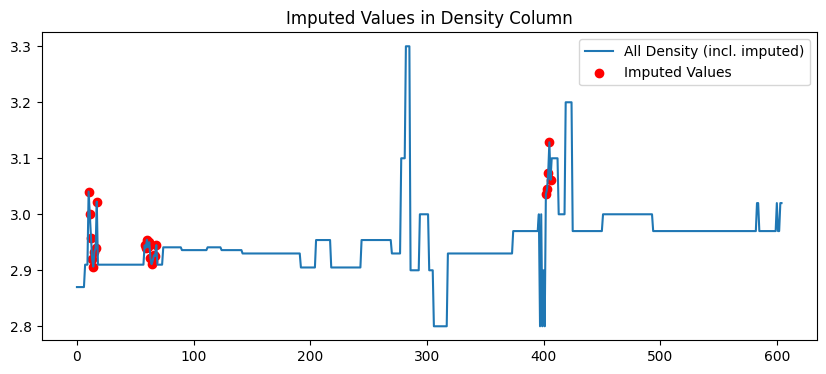

In [28]:
# 결측 여부 마스크
Density_missing_mask = atob['Density'].isna()

# 시각화
plt.figure(figsize=(10, 4))
plt.plot(final_df['Density'], label='All Density (incl. imputed)')
plt.scatter(final_df.index[Density_missing_mask], final_df['Density'][Density_missing_mask], color='red', label='Imputed Values')
plt.legend()
plt.title('Imputed Values in Density Column')
plt.show()


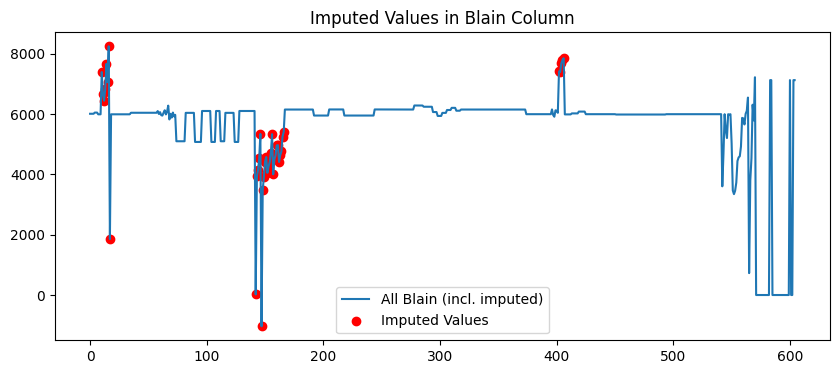

In [29]:
# 결측 여부 마스크
Blain_missing_mask = atob['Blain'].isna()

# 시각화
plt.figure(figsize=(10, 4))
plt.plot(final_df['Blain'], label='All Blain (incl. imputed)')
plt.scatter(final_df.index[Blain_missing_mask], final_df['Blain'][Blain_missing_mask], color='red', label='Imputed Values')
plt.legend()
plt.title('Imputed Values in Blain Column')
plt.show()


---

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 반복 수행 예시 (3번 반복하여 평균)
imputed_values = []
for _ in range(3):
    imp = IterativeImputer(random_state=_)
    imputed = imp.fit_transform(mice_input_df)
    imputed_values.append(imputed)

# 평균 내기
import numpy as np
final_imputed = np.mean(imputed_values, axis=0)
final_df = pd.DataFrame(final_imputed, columns=mice_input_df.columns)
